# De-noising Autoencoder
This exercise aims to recreate the figure from the Alain and Bengio 2013 paper, showing the vector field learned by a de-noising autoencoder.

- What is the purpose recreating the input with and autoencoder model?
    - you can learn how to do tasks on the input, like filtering or filling in gaps.
- Do all autoencoder models have bottlenecks?
    - no, not if the encoder does not compress to a lower dimentions
- What is the difference between an autoencoder and a variational autoencoder?
    - Instead of just learning by weights, learn patterns with VAE Loss

In [ ]:
# Create a simple 2D spiral dataset
import numpy as np

def generating_function(t):
    return np.array([0.04*t*np.sin(t), 0.04*t*np.cos(t)]).T

t = np.random.uniform(3, 12, 1000)
data = generating_function(t)
data

array([[ 0.29987952, -0.14215116],
       [ 0.28620105, -0.17653478],
       [ 0.23671275,  0.16684073],
       ...,
       [ 0.22785365, -0.26367523],
       [-0.0301682 , -0.13127723],
       [-0.19015861,  0.00890276]], shape=(1000, 2))

In [13]:
# Denoising autoencoder
import torch
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self, latent_size=1000, noise_std=0.1):
        super().__init__()
        # Parameters for encoder
        self.b = nn.Parameter(torch.randn(latent_size))
        self.W = nn.Parameter(torch.randn(2,latent_size))

        # Parameters for decoder
        self.c = nn.Parameter(torch.randn(2))
        self.V = nn.Parameter(torch.randn(latent_size,2))

        # Noise standard deviation
        self.noise_std = noise_std
        pass

    def add_noise(self, x):
        x = x.clone()
        x + self.noise_std
        
        return x 

    def forward(self, x):
        x = self.add_noise(x)
        h = torch.tanh(x @ self.W + self.b)
        x = h @ self.V + self.c
        return x

In the paper they were using the BFGS optimizer, but here we will use Adam (since it is much faster). 

It took a few tries to get a good result here (i.e. one that behaves well). You may play with the parameters if you find it helpful; e.g., I had to use a considerable amount of epochs (10000).

- Explain briefly how this objective differs from that of a standard autoencoder.
    - This is not trying to learn the latent space, but just recunstruct without noise

In [ ]:
# Training the denoising autoencoder
device = 'mps' if torch.cuda.is_available() else 'cpu'

model = DenoisingAutoencoder(
    noise_std=0.01, latent_size=1000).to(device=device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

loss_fn = nn.MSELoss()

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

model.train()
# Training loop
for epoch in range(1000):
    for i in range(0, data_tensor.size(0), 100):
        batch = data_tensor[i:i+100]
        pred = model(batch)
        pred = pred.squeeze()
        loss = loss_fn(pred, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:<4} | reconstruction loss = {loss.item():.4f}")

Epoch 0    | reconstruction loss = 182.6672
Epoch 1000 | reconstruction loss = 0.0005


KeyboardInterrupt: 

/var/folders/4w/g8b9hb551_n3042tz3nhkpj80000gn/T/ipykernel_50398/3046320393.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residual = np.multiply(residual, 0.1)  # scale down for better visualization


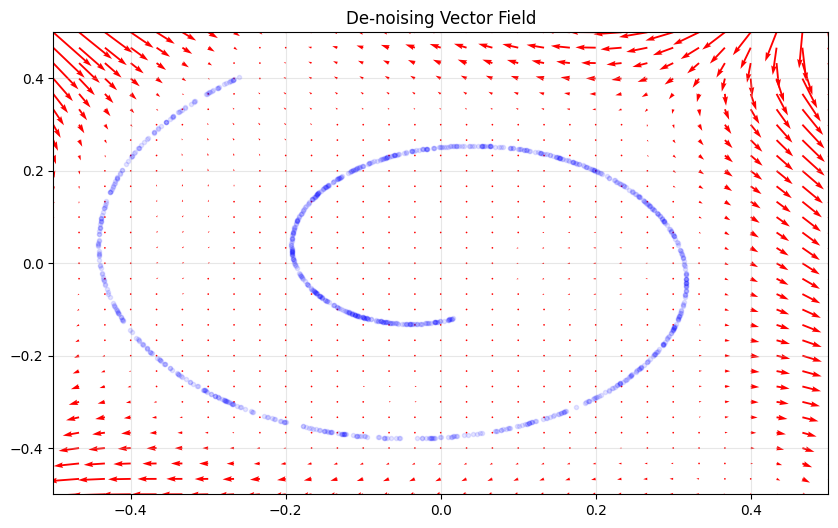

In [22]:
# Visualize how the autoencoder corrects the input
import matplotlib.pyplot as plt

model.eval()

x = torch.linspace(-0.5, 0.5, 31)
y = torch.linspace(-0.5, 0.5, 31)

X, Y = torch.meshgrid(x, y, indexing='ij')
grid_points = torch.stack([X.ravel(), Y.ravel()], dim=-1).to(device)

### YOUR CODE HERE: Compute the residuals r(x) - x
with torch.no_grad():
    
    residual = model(grid_points) - grid_points
    
residual = np.multiply(residual, 0.1)  # scale down for better visualization
residual = residual.cpu().numpy()

# Plot the vector field
plt.figure(figsize=(10, 6))
plt.quiver(grid_points[:, 0], grid_points[:, 1],
           residual[:, 0], residual[:, 1],
           angles='xy', scale_units='xy', scale=1, color='r')
plt.plot(data[:, 0], data[:, 1], 'b.', alpha=0.1)  # Plot the original data points
plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.grid(alpha=0.3)
plt.title("De-noising Vector Field")
plt.show()